In [1]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt


In [2]:
data = np.load(r"C:\Users\ASUS\Downloads\PEMS08.npz\PEMS08.npz")

arr = data['data']            # (time, sensors, features)
flow = arr[:,:,0]             # traffic flow feature


In [3]:
split_index = int(0.8 * len(flow))

train_flow = flow[:split_index]

mean = train_flow.mean()
std  = train_flow.std()

flow = (flow - mean) / std


In [7]:
SEQ_LEN = 36
PRED_LEN = 1

X=[]
Y=[]

for i in range(len(flow)-SEQ_LEN-PRED_LEN):
    X.append(flow[i:i+SEQ_LEN])
    Y.append(flow[i+SEQ_LEN:i+SEQ_LEN+PRED_LEN])

X=np.array(X)
Y=np.array(Y)

split=int(0.8*len(X))

X_train_full = X[:split]
Y_train_full = Y[:split]

X_test = X[split:]
Y_test = Y[split:]

# validation split from train
val_split = int(0.9*len(X_train_full))

X_train = X_train_full[:val_split]
Y_train = Y_train_full[:val_split]

X_val = X_train_full[val_split:]
Y_val = Y_train_full[val_split:]



In [11]:
class LSTMTransformer(nn.Module):
    def __init__(self,sensors=170,hidden=128):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=sensors,
            hidden_size=hidden,
            num_layers=2,
            batch_first=True
        )

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden,
            nhead=8,
            dim_feedforward=256,
            dropout=0.1,
            batch_first=True
        )

        self.transformer = nn.TransformerEncoder(encoder_layer,num_layers=3)
        self.fc = nn.Linear(hidden,sensors)

    def forward(self,x):
        x,_ = self.lstm(x)
        x = self.transformer(x)
        x = self.fc(x[:,-1,:])
        return x.unsqueeze(1)


In [10]:
torch.set_num_threads(8)
device = torch.device("cpu")
print("Using device:", device)


Using device: cpu


In [12]:
model=LSTMTransformer().to(device)

optimizer=torch.optim.Adam(model.parameters(),lr=0.00012)
criterion=nn.MSELoss()

EPOCHS=100
patience=10
best_val_loss=float("inf")
patience_counter=0

for epoch in range(EPOCHS):

    # training
    model.train()
    train_loss=0

    for x,y in train_loader:
        x,y=x.to(device),y.to(device)

        optimizer.zero_grad()
        pred=model(x)

        loss=criterion(pred,y)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(),1.0)
        optimizer.step()

        train_loss+=loss.item()

    train_loss/=len(train_loader)

    # validation
    model.eval()
    val_loss=0

    with torch.no_grad():
        for x,y in val_loader:
            x,y=x.to(device),y.to(device)
            pred=model(x)
            val_loss+=criterion(pred,y).item()

    val_loss/=len(val_loader)

    print(f"Epoch {epoch+1}, Train {train_loss:.4f}, Val {val_loss:.4f}")

    # early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(),"best_model.pth")
    else:
        patience_counter += 1

    if patience_counter >= patience:
        print("Early stopping triggered")
        break

model.load_state_dict(torch.load("best_model.pth"))


Epoch 1, Train 0.2393, Val 0.1344
Epoch 2, Train 0.0716, Val 0.1156
Epoch 3, Train 0.0563, Val 0.1064
Epoch 4, Train 0.0483, Val 0.0996
Epoch 5, Train 0.0432, Val 0.0936
Epoch 6, Train 0.0399, Val 0.0903
Epoch 7, Train 0.0375, Val 0.0869
Epoch 8, Train 0.0356, Val 0.0827
Epoch 9, Train 0.0342, Val 0.0800
Epoch 10, Train 0.0329, Val 0.0780
Epoch 11, Train 0.0319, Val 0.0755
Epoch 12, Train 0.0310, Val 0.0735
Epoch 13, Train 0.0303, Val 0.0727
Epoch 14, Train 0.0296, Val 0.0707
Epoch 15, Train 0.0290, Val 0.0688
Epoch 16, Train 0.0285, Val 0.0676
Epoch 17, Train 0.0280, Val 0.0661
Epoch 18, Train 0.0276, Val 0.0651
Epoch 19, Train 0.0272, Val 0.0632
Epoch 20, Train 0.0268, Val 0.0627
Epoch 21, Train 0.0264, Val 0.0617
Epoch 22, Train 0.0261, Val 0.0612
Epoch 23, Train 0.0258, Val 0.0595
Epoch 24, Train 0.0255, Val 0.0598
Epoch 25, Train 0.0253, Val 0.0581
Epoch 26, Train 0.0250, Val 0.0578
Epoch 27, Train 0.0248, Val 0.0572
Epoch 28, Train 0.0246, Val 0.0557
Epoch 29, Train 0.0243, Val 0

<All keys matched successfully>

MAE: 16.401759680869652
RMSE: 24.84961621304351
MAPE: 158770.17354440744


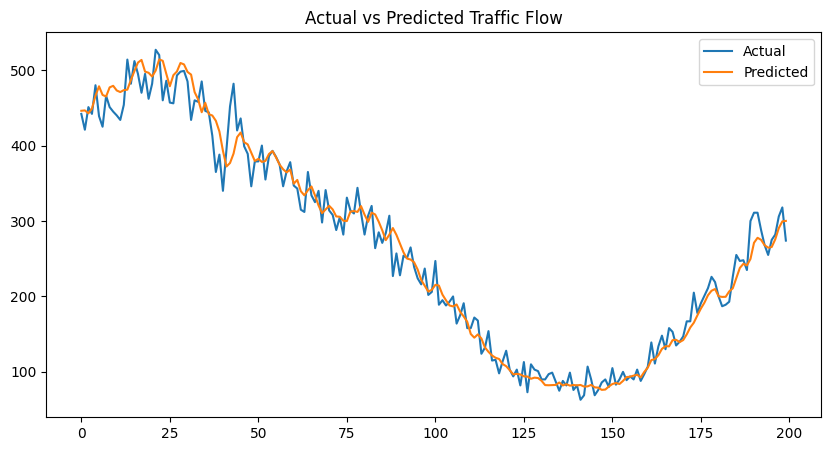

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error

model.eval()

preds=[]
actual=[]

with torch.no_grad():
    for x,y in test_loader:
        x=x.to(device)
        out=model(x)

        preds.append(out.cpu().numpy())
        actual.append(y.numpy())

preds=np.concatenate(preds)
actual=np.concatenate(actual)

# denormalize
preds = preds * std + mean
actual = actual * std + mean

# metrics
mae = mean_absolute_error(actual.flatten(), preds.flatten())
rmse = np.sqrt(mean_squared_error(actual.flatten(), preds.flatten()))

# MAPE
mape = np.mean(np.abs((actual.flatten() - preds.flatten()) / (actual.flatten() + 1e-5))) * 100

print("MAE:", mae)
print("RMSE:", rmse)
print("MAPE:", mape)

# graph
plt.figure(figsize=(10,5))
plt.plot(actual[:200,0,0], label="Actual")
plt.plot(preds[:200,0,0], label="Predicted")
plt.legend()
plt.title("Actual vs Predicted Traffic Flow")
plt.show()
